In [65]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate

io passo r e v, quindi loro li considero parametri

In [66]:
def delta(i, j):
    return 1 if i == j else 0

In [ ]:
def ODE(x, v, a, M):

    K = (x[0]**2 + x[1]**2 + x[2]**2 - a**2)/2
    W = np.sqrt(K**2 + a**2*x[2]**2)
    r = np.sqrt(K + W )
    rho2 = r**2 + a**2
    rho = np.sqrt(rho2)

    eta = np.diag([-1, 1, 1, 1])

    di_W = np.array([
        K*x[0] / W,
        K*x[1] / W,
        x[2]*(K + a**2) / W
    ])

# layer 1
    di_r = np.array([
        x[0]*r / (2*W),
        x[1]*r / (2*W),
        x[2]*rho**2 / (2*r*W)
    ])

# layer 2

    S = 2*r**2*W
    di_S = np.array([
        2*x[0]*r**4 / W,
        2*x[1]*r**4 / W,
        2*r**2*rho2*x[2] / W + 2*a**2*x[2]
    ])

# layer 3

    f = M*r / W
    di_f = M * (di_r - di_W * r / W) / W
    
#layer 4

    shape_factor = np.array([
        (x[0]*(a**2 - r**2) -2*a*r*x[1]) / rho2**2,
        (x[1]*(a**2 - r**2) + 2*a*r*x[0]) / rho2**2,
        -x[2]/r**2       
    ])
    

    l_down = np.array([
        1,
        (r*x[0] + a*x[1]) / rho2,
        (r*x[1] - a*x[0]) / rho2,
        x[2] / r
    ])

    # l_up = np.matmul(eta, l_down)

    delta_ij = np.eye(3) # matrice identità 3x3 non so se sia più comoda lei o la chiamata di una funzione delta(i, j)
    dili = np.zeros((3, 4))

    dili[:, 1] = (r * delta_ij[:, 0] + a * delta_ij[:, 1]) / rho2 + shape_factor[0] * di_r
    dili[:, 2] = (r * delta_ij[:, 1] - a * delta_ij[:, 0]) / rho2 + shape_factor[1] * di_r
    dili[:, 3] = delta_ij[:, 2] / r + shape_factor[2] * di_r

    # layer 5

    term1 = np.einsum('k, u, v -> kuv', di_f, l_down, l_down)
    term2 = f * np.einsum('ku, v -> kuv', dili, l_down)
    term3 = f * np.einsum('u, kv -> kuv', l_down, dili)

    d_g = term1 + term2 + term3
    # print(d_g.shape)

    d4_g = np.zeros((4, 4, 4))
    d4_g[1:, :, :] = d_g


    #layer 6

    l_up = np.array([-1, l_down[1], l_down[2], l_down[3]])

    G_ab = np.einsum('s, abs -> ab', l_up, d4_g) +\
           np.einsum('s, bas -> ab', l_up, d4_g) -\
           np.einsum('s, sab -> ab', l_up, d4_g)
    
    print(G_ab)
    
    v_4 = np.array([1, v[0], v[1], v[2]]) #osservatore distante ma poi mi rivedo bene la spiegazione di questo.

    G_scalar = np.einsum('ab, a, b ->', G_ab, v_4, v_4)

    #simboli di Christoffel

    term_a = np.einsum('us, abs -> uab', eta, d4_g)
    term_b = np.einsum('us, bas -> uab', eta, d4_g)
    term_s = np.einsum('us, sab -> uab', eta, d4_g)
    Gamma_bar = 0.5 * (term_a + term_b - term_s)

    Gamma_bar_vv = np.einsum('uab, a, b -> u', Gamma_bar, v_4, v_4)

    F = -Gamma_bar_vv[1:] + Gamma_bar_vv[0]*v

    dv_dt = F + (f/2)*G_scalar*(l_down[1:] + v)

    return dv_dt

In [72]:
x = np.array([1, 2, 3])
v = np.array([0, 0, 0])

f = ODE(x, v, 0, 1)

In [68]:
def derivative( t, y, a, M):
    x = y[:3]
    v = y[3:]
    dv_dt = ODE(x, v, a, M)
    return np.concatenate((v, dv_dt))

In [69]:
#condizioni iniziali

a = 0
M = 1
e = 0.0
p = 50 * M

h= 1

t0 = 0
t_end = 15000
t_range = (t0, t_end)
t_eval = np.linspace(t_range[0], t_range[1], 10000)

y0 = np.array([50, 0, 0, 0, 0.14142136, 0])

In [70]:
sol = scipy.integrate.solve_ivp(derivative, t_range, y0, args=(a, M), method='DOP853', rtol=1e-11, atol=1e-13, t_eval=t_eval)
t = sol.t
y = sol.y.T
status = sol.status

print (status)
print (y[0])

0
[50.          0.          0.          0.          0.14142136  0.        ]


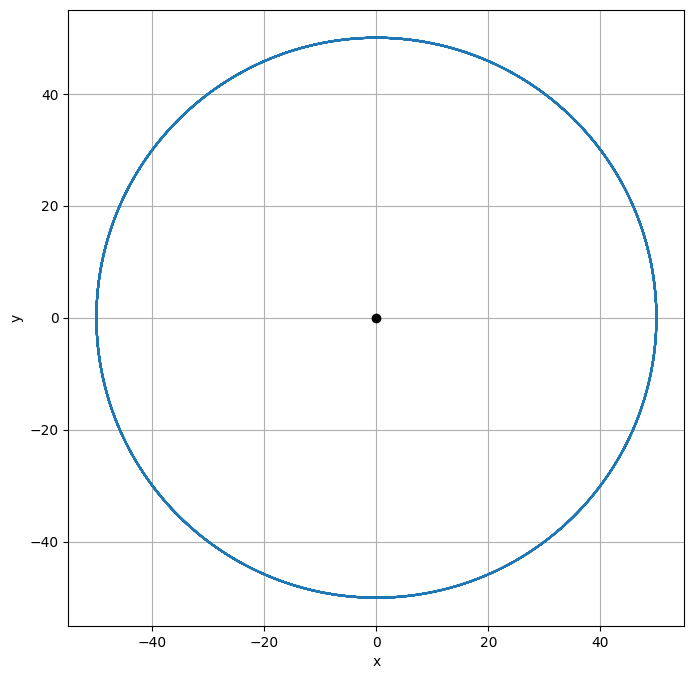

In [71]:
fig, ax = plt.subplots(figsize=(10,8))

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_aspect('equal')

ax.plot(y[:, 0], y[:, 1])
plt.plot(0, 0, 'ko', label="Buco Nero")

ax.grid()
plt.show()